## Exploratory Data Analysis

### Code Documentation & Explanation Guide

#### Students Involved:
* **Adam Idlan bin Azmir** (2415935)
* **Ahmad Adam Hakimi bin Naeman** (2418711)
* **Muhammad Adam Iskandar bin Sidi** (2411925)
* **Muhammad Adil bin Sahrolnizam** (2418733)

##### There are 6 steps to begin the EDA process : 
* **0. System Setup & Core Libraries Implementation**
* **1. Class Distribution & Frequency Scans**
* **2. Categorical Visualization Bar Charts & Proportions**
* **3. Image Data Quality & Profiling**
* **4. Spatial Aspect Ratio & Dimension Plots**
* **5. Color Space Profiling & Channel Analytics**
* **6. Summary of EDA**

#### 0. System Setup & Core Libraries Implementation
* **We initializing common and important computational libraries like for this project**
* **We defining the path of the dataset for EDA process**

### 🛠️ Core Libraries Reference Table

| Library / Module | Import Alias | Structural Function in the EDA Pipeline |
| :--- | :---: | :--- |
| **`os`** | `import os` | **Operating System Interface:** Handles folder traversal, lists disease class sub-directories, safely joins paths, and counts physical files on disk. |
| **`numpy`** | `import np` | **Scientific Computing:** Converts pixel grids into multi-dimensional numerical tensors (arrays) and handles high-performance matrix calculations. |
| **`pandas`** | `import pd` | **Data Manipulation:** Structures collected metadata (file counts, image paths, sizes) into organized tabular DataFrames for mapping and analysis. |
| **`matplotlib.pyplot`** | `import plt` | **Foundational Plotting:** Acts as the primary state-based plotting engine used to build figures, adjust chart sizes, and display graph windows. |
| **`matplotlib.image`** | `import mpimg` | **Image Loading Utility:** Specifically optimized to stream, parse, and read raw image binary files into readable pixel arrays directly within Matplotlib. |
| **`seaborn`** | `import sns` | **Statistical Visualization:** Implements advanced high-level styling wrappers over Matplotlib to create clean histograms, KDE curves, and strip borders (`despine`). |
| **`PIL.Image`** | `from PIL import Image` | **Pillow Core Engine:** Opens raw file headers to profile spatial dimensions (widths/heights) without loading heavy image pixel arrays into RAM memory. |
| **`collections.Counter`** | `from collections import Counter` | **Frequency Accounting:** A high-speed tracking tool used to tally, group, and calculate distinct value or class occurrences across data lists instantly. |
| **`warnings`** | `import warnings` | **Runtime Alert Management:** Provides systematic programmatic control over how the Python environment interprets and displays background warning alerts. |
| **`warnings.filterwarnings`**| `"ignore"` | **Log Suppression:** Instructs the runtime interpreter to silence non-breaking warnings or deprecation alerts, keeping execution logs clean. |



In [ ]:
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

In [27]:
DATASET_PATH = "C:/Users/AHMAD ADAM HAKIMI/Downloads/Machine_Learning_Project/PlantVillage"

### Step 1: Class Distribution & Frequency Scans

#### 1.1 Overview of the Code Block
This block acts as a directory scanner. Its main job is to programmatically crawl through your raw dataset path, find all individual disease categories (sub-folders), and tally up exactly how many images exist inside each category. By doing this, we get a text-based terminal report showing whether our dataset is balanced or heavily skewed towards a specific type of tomato disease before any visualization happens.

#### 1.2 Variable Breakdown Table

| Variable Name | Data Type | Structural Function in Code |
| :--- | :---: | :--- |
| **`class_names`** | `list` (Strings) | Stores the sorted names of all sub-directories (disease classes) found inside the main dataset path. |
| **`class_counts`** | `dict` (Key-Value) | Acts as a lookup ledger mapping each disease class name (Key) to its exact total image count (Value). |
| **`cls`** | `string` | The active loop variable representing the single disease class folder being scanned at that moment. |
| **`cls_path`** | `string` | Stores the dynamically built absolute system path to the specific class folder being scanned. |
| **`images`** | `list` (Strings) | A temporary collection storing valid file names that match our allowed image extensions inside the active directory. |
| **`total_images`** | `int` | Holds the mathematical sum of every single valid image across all classes combined. |
| **`bar`** | `string` | A visual formatting string made of `#` symbols used to draw a text-based horizontal bar chart in the terminal. |

#### 1.3 Line-by-Line Code Explanation

* `print("=" * 60)` & `print(...)`
  * Draws a clean horizontal separator header using sixty `=` characters to cleanly frame our terminal console output report.
* `class_names = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))])`
  * Scans your main path, filters out non-folder assets (keeping only folders), extracts their folder text names, and sorts them alphabetically so your target class indexes stay predictable.
* `class_counts = {}`
  * Initializes an empty dictionary ledger to begin storing the structural frequency mapping of `Class_Name : Total_Images`.
* `for cls in class_names:`
  * Sets up a definite iteration loop to move step-by-step into every single disease folder discovered on disk.
* `cls_path = os.path.join(DATASET_PATH, cls)`
  * Dynamically joins the root path directory with the active loop sub-folder string to ensure cross-platform safe file routing.
* `images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]`
  * Scans inside that specific folder and uses list comprehension to index only files whose extensions end with standard computer vision formats.
* `class_counts[cls] = len(images)`
  * Counts the total length of the filtered image list and writes that integer metadata value straight into our `class_counts` dictionary ledger.
* `total_images = sum(class_counts.values())`
  * Takes all the calculated integer counts out of our ledger dictionary and sums them up to establish the absolute population size of the dataset.
* `bar = '#' * (count // 50)`
  * A clever display logic scaling trick. It takes the total count of images in that specific class, performs integer division by 50, and generates that exact number of `#` characters to form a rapid text bar.
* `print(f" {cls:<45} {count:>5} images {bar} ")`
  * Leverages clean string padding: formats the class name string left-aligned inside 45 slots (`<45`), right-aligns the count numbers inside 5 slots (`>5`), and appends the custom text bar right at the end.


In [28]:
# Displaying the header as starting point of EDA
print("=" * 60)
print("  EDA - PlantVillage Tomato Dataset")
print("=" * 60)

# Getting the class names from the dataset directory
class_names = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])

# Counting the number of images in each class
class_counts = {}
for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(images)

# Displaying the class distribution
total_images = sum(class_counts.values())
print(f"\nTotal classes found : {len(class_names)}")
print(f"Total images found : {total_images}\n")
print("Class breakdown:")
for cls, count in class_counts.items():
    bar = '#' * (count // 50)
    print(f" {cls:<45} {count:>5} images {bar} ")

  EDA - PlantVillage Tomato Dataset

Total classes found : 10
Total images found : 16011

Class breakdown:
 Tomato_Bacterial_spot                          2127 images ########################################## 
 Tomato_Early_blight                            1000 images #################### 
 Tomato_Late_blight                             1909 images ###################################### 
 Tomato_Leaf_Mold                                952 images ################### 
 Tomato_Septoria_leaf_spot                      1771 images ################################### 
 Tomato_Spider_mites_Two_spotted_spider_mite    1676 images ################################# 
 Tomato__Target_Spot                            1404 images ############################ 
 Tomato__Tomato_YellowLeaf__Curl_Virus          3208 images ################################################################ 
 Tomato__Tomato_mosaic_virus                     373 images ####### 
 Tomato_healthy                                 1

### Step 1 (Continued): Categorical Visualizations & Baseline Metrics

#### 1.4 Overview of the Visualization Block
This sub-block translates our raw directory counts into a high-quality, professional bar chart using Matplotlib and Seaborn. The main goal here is to map out our metrics visually so we can immediately identify which tomato leaf classes are overrepresented (excessive data) or underrepresented (scarce data). It also strikes a red dashed reference line representing the dataset's true mathematical mean (average), serving as our baseline indicator for evaluating class imbalance before data preprocessing.

#### 1.5 Variable Breakdown Table

| Variable Name | Data Type | Structural Function in Code |
| :--- | :---: | :--- |
| **`fig`** | `matplotlib.figure.Figure` | The top-level canvas wrapper object that contains and manages the overall figure layout boundaries. |
| **`ax`** | `matplotlib.axes._subplots.AxesSubplot` | The active sub-plot coordinate space where elements like columns, tick marks, text values, and reference vectors are drawn. |
| **`colors`** | `numpy.ndarray` (RGBA Matrix) | A continuous spectrum arrays of qualitative soft pastel tones dynamically sliced out from the 'Set3' discrete colormap engine. |
| **`bars`** | `matplotlib.container.BarContainer` | A composite graphical container that locks together structural metadata for all generated rectangular bar objects. |
| **`bar`** | `matplotlib.patches.Rectangle` | The targeted iteration item denoting a single specific vertical bar element on the layout space. |
| **`count`** | `int` | The corresponding frequency metric mapping the precise sample weight linked directly to the loop's current bar. |

#### 1.6 Line-by-Line Code Explanation

* `fig, ax = plt.subplots(figsize=(14, 6))`
  * Sets up a spacious drawing envelope spanning 14 inches wide by 6 inches high. `fig` instantiates the macro backdrop board, whereas `ax` provides the individual plot matrix.
* `colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))`
  * Evenly divides a color wheel mapping configuration between 0 and 1 using your total number of unique disease classes. It assigns a pleasant soft pastel hue (`Set3`) to each class for clean presentation aesthetics.
* `bars = ax.bar(range(len(class_names)), list(class_counts.values()), color=colors, edgecolor='white', linewidth=0.8)`
  * Plots our core data pillars. It renders horizontal placement indices across the X-axis against our accumulated integer count metrics along the Y-axis. It applies a crisp white boundary edge line around each bar for maximum separation.
* `for bar, count in zip(bars, class_counts.values()):`
  * Employs an explicit multi-iterable loop mechanism to trace through every structural bar patch object paired alongside its matching raw item metric concurrently.
* `ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')`
  * Dynamically extracts the horizontal center and topmost vertical edge of each column bar to stamp its precise digital data count. It sets horizontal alignment to center (`ha='center'`) and enforces bold typography for clarity.
* `ax.set_xticks(range(len(class_names)))` & `ax.set_xticklabels([...], rotation=45, ha='right')`
  * Formats the horizontal labels. To prevent cluttered text strings, it strips out long, redundant string headers like `'Tomato_'` or `'Tomato__'`, trades underscores for sharp line breaks (`\n`), and angles labels 45 degrees to optimize spacing.
* `ax.set_title(...)`, `ax.set_xlabel(...)`, `ax.set_ylabel(...)`
  * Establishes the descriptive, bold main chart title alongside corresponding labels for the independent variable axis (Tomato Disease Class) and the dependent variable axis (Image Sample Count).
* `ax.axhline(y=total_images/len(class_names), color='red', linestyle='--', linewidth=1.2, label=f'Mean...')`
  * Strikes a fixed, horizontal trend line across the entire grid canvas representing our absolute dataset average. If certain disease columns break out way past or fall heavily short of this vector, it signals potential deep learning model bias risks.
* `ax.legend(fontsize=10)`
  * Instantiates a text descriptor card identifying what the horizontal red vector line signifies to a reviewer tracking down the data balance attributes.
* `sns.despine()`
  * Trims away the unneeded bounding frame lines from the top and right side of the graph, modernizing the chart's structural footprint.
* `plt.tight_layout()`
  * Instructs the display interface to automatically scale all internal margins, protecting long axis labels or padding elements from getting clipped at the canvas perimeter.
* `plt.savefig('EDA_logs/eda_01_class_distribution.png', dpi=150, bbox_inches='tight')`
  * Serializes and writes out the visualization asset directly to our disk cache path, printing at a crisp 150 DPI with edge padding pulled tight (`bbox_inches='tight'`)—ready for presentation slides or project documentation.


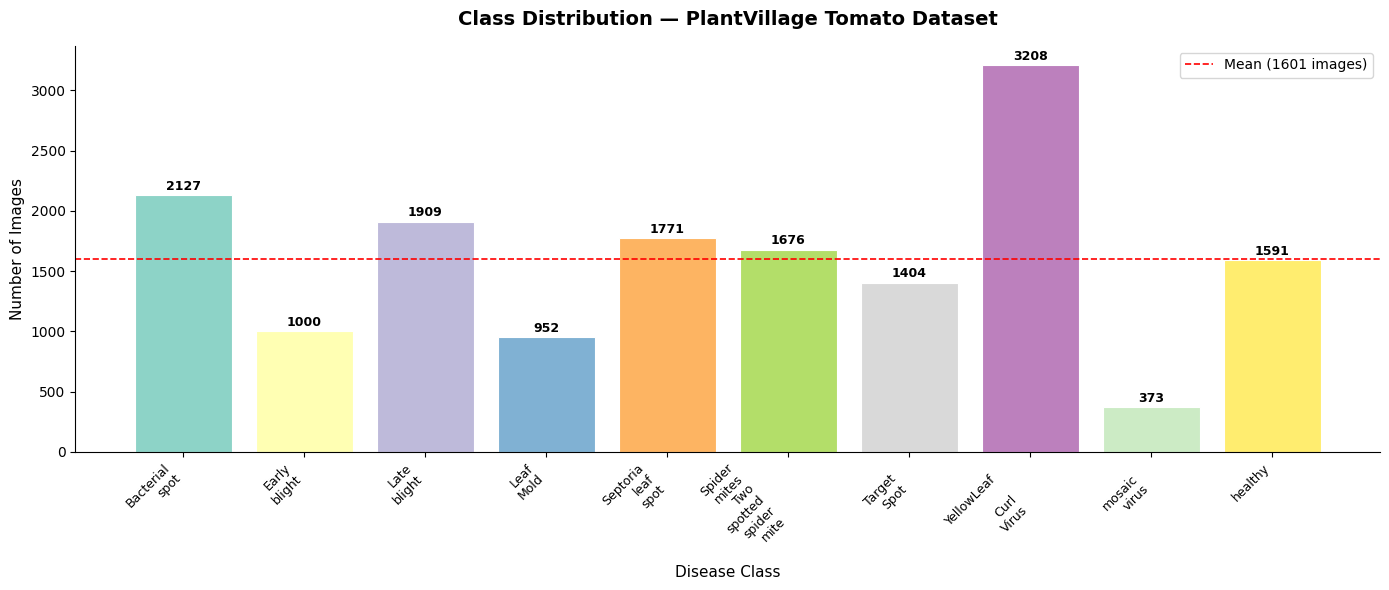


✅ Saved: eda_01_class_distribution.png


In [ ]:
# Visualizing the class distribution with a bar chart
fig, ax = plt.subplots(figsize=(14, 6))
colors = plt.cm.Set3(np.linspace(0, 1, len(class_names)))
bars = ax.bar(range(len(class_names)), list(class_counts.values()),
              color=colors, edgecolor='white', linewidth=0.8)

# Add value labels on top of bars
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(count), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Customizing x-axis labels
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(
    [c.replace('Tomato_', '').replace('Tomato__', '').replace('_', '\n')
     for c in class_names],
     rotation=45, ha='right', fontsize=9
)
ax.set_title('Class Distribution — PlantVillage Tomato Dataset',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Disease Class', fontsize=11)
ax.set_ylabel('Number of Images', fontsize=11)
ax.axhline(y=total_images/len(class_names), color='red',
           linestyle='--', linewidth=1.2, label=f'Mean ({total_images//len(class_names)} images)')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()

# Save the figure
plt.savefig('EDA_logs/eda_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Saved: eda_01_class_distribution.png")

### Step 2: Categorical Visualization (Class Proportions Pie Chart)

#### 2.1 Overview of the Visualization Block
This sub-block takes the numeric frequency totals and displays them using a highly detailed pie chart layout. While the bar chart in Step 1 highlighted raw count variations against a mean baseline, this pie chart shifts our focus to the exact percentage weights. It calculates the proportion each disease category takes up relative to the entire dataset, which is crucial for answering the core machine learning question: *"Is our dataset structurally balanced or mathematically skewed?"*


#### 2.2 Variable Breakdown Table

| Variable Name | Data Type | Structural Function in Code |
| :--- | :---: | :--- |
| **`fig`** | `matplotlib.figure.Figure` | The main visual window container managing the canvas dimensions. |
| **`ax`** | `matplotlib.axes._subplots.AxesSubplot` | The specific chart plane where the circles, text percentages, and legends are projected. |
| **`short_labels`** | `list` (Strings) | A list of modified class names with long system prefixes trimmed out to fit cleanly around the pie slices. |
| **`wedges`** | `list` (`matplotlib.patches.Wedge`) | A collection storing the structural metadata for each individual colored slice of the pie chart. |
| **`texts`** | `list` (`matplotlib.text.Text`) | A collection holding the text label objects located on the outside perimeter of each chart wedge. |
| **`autotexts`** | `list` (`matplotlib.text.Text`) | A collection holding the generated numeric percentage label strings rendered inside the wedges. |
| **`text`** | `matplotlib.text.Text` | The active loop iterator variable used to apply individual styling passes over the outer labels. |
| **`autotext`** | `matplotlib.text.Text` | The active loop iterator variable used to apply micro-scale styling directly to inner percentage text. |

#### 2.3 Line-by-Line Code Explanation

* `fig, ax = plt.subplots(figsize=(10, 8))`
  * Sets up a dedicated square-proportioned drawing canvas measuring 10x8 inches to ensure the pie chart elements preserve a perfect circular aspect ratio without oval distortion.
* `short_labels = [c.replace('Tomato_', '').replace('Tomato__', '') for c in class_names]`
  * Loops through your raw string class indices to strip away redundant computer vision database prefixes. This leaves short, clean text labels ready to fit the diagram cleanly.
* `wedges, texts, autotexts = ax.pie(...)`
  * The main structural execution command to render the pie chart! It takes three main outputs:
    * `list(class_counts.values())`: Supplies the raw sample counts which control the surface area sizing of each slice.
    * `labels=short_labels`: Attaches our newly trimmed disease strings to their corresponding slices.
    * `autopct='%1.1f%%'`: Instructs the layout generator to automatically compute individual slice percentages down to a single decimal precision point.
    * `startangle=140`: Rotates the base origin point of the first slice 140 degrees counterclockwise to establish a neat visual orientation.
    * `colors=colors`: Applies our pre-configured qualitative pastel palette to the slices.
    * `pctdistance=0.82`: Radiates the internal percentage indicators outward to sit at exactly 82% from the absolute center, keeping them clear of crowding.
* `for text in texts: text.set_fontsize(8)`
  * Loops over every external disease descriptor label and locks its font layout to size 8 to prevent massive string overlaps on the outer edges.
* `for autotext in autotexts: autotext.set_fontsize(7)`
  * Iterates across the inside calculated percentage texts, shrinking them safely down to font size 7 so they fit cleanly within narrower wedges without clipping.
* `ax.set_title('Proportion of Each Class\n(Is Dataset Balanced?)', fontsize=13, fontweight='bold')`
  * Sets a bold main header explaining the purpose of the plot, breaking it into two lines (`\n`) for optimal vertical spacing.
* `plt.tight_layout()`
  * Enforces container bounding guidelines to automatically trim external padding and prevent labels from clipping off the edges of your presentation layout.
* `plt.savefig('EDA_logs/eda_02_class_proportion.png', dpi=150, bbox_inches='tight')`
  * Encapsulates the visual asset and streams it out onto disk storage as a sharp 150 DPI `.png` file with zero unnecessary white edge margins (`bbox_inches='tight'`).



✅ Saved: eda_02_class_proportion.png


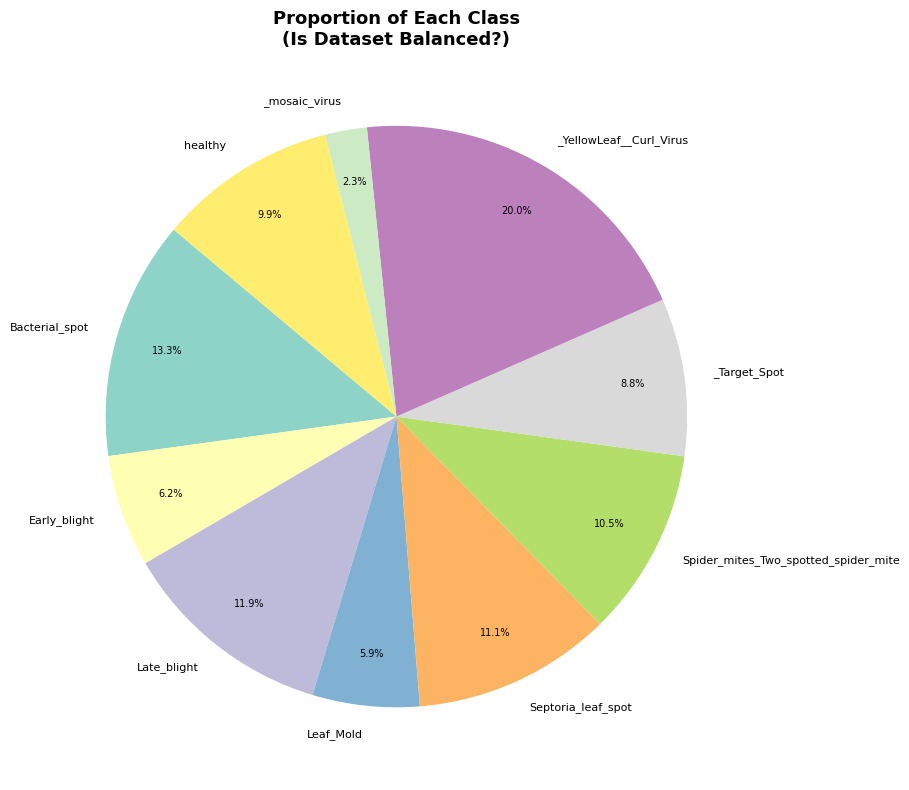

In [37]:
fig, ax = plt.subplots(figsize=(10, 8))
short_labels = [c.replace('Tomato_', '').replace('Tomato__', '')
                for c in class_names]
wedges, texts, autotexts = ax.pie(
    list(class_counts.values()),
    labels=short_labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.82,
)
for text in texts:
    text.set_fontsize(8)
for autotext in autotexts:
    autotext.set_fontsize(7)
ax.set_title('Proportion of Each Class\n(Is Dataset Balanced?)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_logs/eda_02_class_proportion.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved: eda_02_class_proportion.png")

### Step 3: Image Data Quality & Profiling (Sample Image Previews)

#### 3.1 Overview of the Visualization Block
This sub-block handles our first visual verification of the raw image data quality. Instead of blindly processing files, it creates a $2 \times 5$ multi-panel image gallery displaying the very first image sample from each of our 10 tomato disease classes. This allows us to inspect the visual characteristics of the leaves—such as background lighting conditions, leaf orientation, and lesion textures—and flags any broken, corrupted, or non-image files before we start deep learning training.


#### 3.2 Variable Breakdown Table

| Variable Name | Data Type | Structural Function in Code |
| :--- | :---: | :--- |
| **`fig`** | `matplotlib.figure.Figure` | The main outer canvas layout window managing our global gallery panel boundary dimensions. |
| **`axes`** | `numpy.ndarray` (Flattened) | A 1D flattened array tracking all 10 individual grid subplot boxes for sequential image plotting. |
| **`idx`** | `int` | The active position counter tracking our progress from plot box 0 to 9 in the gallery grid loop. |
| **`cls`** | `string` | The active loop variable representing the name of the specific disease category directory being accessed. |
| **`cls_path`** | `string` | Stores the dynamically built file path to the disease sub-folder currently under inspection. |
| **`imgs`** | `list` (Strings) | A fast local collection indexing valid image filenames inside the current sub-folder. |
| **`img_path`** | `string` | Stores the exact localized file address pointing straight to the target first sample image. |
| **`img`** | `numpy.ndarray` (RGB Pixel Tensor) | The numerical multi-dimensional pixel matrix containing the loaded image data read into memory. |
| **`short_name`** | `string` | The streamlined disease class name with long system data prefixes and hyphens stripped out for clean titles. |


#### 3.3 Line-by-Line Code Explanation

* `fig, axes = plt.subplots(2, 5, figsize=(18, 8))`
  * Books an empty structural display canvas grid consisting of 2 horizontal rows and 5 vertical columns (`2, 5`), giving us 10 plot boxes total inside an 18x8 inch boundary.
* `axes = axes.flatten()`
  * Flattens our $2 \times 5$ matrix grid from a 2D array down into a flat 1D sequence array containing 10 slots (index 0 to 9) so we can loop through each box sequentially with a single pointer index.
* `for idx, cls in enumerate(class_names):`
  * Initiates an indexed iteration loop across our sorted list of tomato disease classes. `idx` keeps track of the target grid box while `cls` fetches the active folder string name.
* `cls_path = os.path.join(DATASET_PATH, cls)`
  * Securely joins the root workspace directory with our current disease string to locate the target sub-folder on disk.
* `imgs = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]`
  * Performs a quick directory scan, filtering out hidden operating system assets and keeping only standard image file formats.
* `if imgs:`
  * A crucial logical boundary check. It ensures the class folder actually contains valid data before attempting to read a file, preventing the execution engine from throwing an error.
* `img_path = os.path.join(cls_path, imgs[0])`
  * Selects the very first available image filename inside the class folder (`imgs[0]`) and compiles its absolute target system address path.
* `img = mpimg.imread(img_path)`
  * Streams the raw binary image data file from your drive and decodes it straight into a standard numerical multi-dimensional pixel tensor.
* `axes[idx].imshow(img)`
  * Feeds the raw pixel tensor array directly into the active grid slot to render the visual photograph onto your notebook screen.
* `short_name = cls.replace('Tomato_', '').replace('Tomato__', '').replace('-', '')`
  * Cleans up the string by stripping away messy or redundant database headers and hyphens, making the title neat and presentable.
* `axes[idx].set_title(short_name, fontsize=9, fontweight='bold', wrap=True)`
  * Attaches our cleaned disease title above its matching image slot using small, bold typography. The `wrap=True` parameter automatically pushes long text onto a second line if it gets too wide.
* `axes[idx].axis('off')`
  * Hides the coordinate axis lines and ticks (X and Y pixel rulers) around each individual picture box, turning our plot layout into a clean, professional gallery view.
* `for i in range(len(class_names), len(axes)): axes[i].set_visible(False)`
  * Safety logic cleanup. If your grid setup has extra unused plotting panels left over at the end, this loop automatically switches their visibility property to `False`, making them completely invisible.
* `plt.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold', y=1.01)`
  * Stamps a prominent master title over the entire display layout, positioning it slightly upward (`y=1.01`) so it sits cleanly above our top grid row.
* `plt.tight_layout()`
  * Tells the plot window to automatically scale internal padding margins to guarantee labels and leaf photographs never crush into each other.
* `plt.savefig('EDA_logs/eda_03_sample_images.png', dpi=150, bbox_inches='tight')`
  * Compiles the finished multi-panel visual asset and saves it out to disk as a 150 DPI `.png` file with all unnecessary white margins removed—ideal for quick references or documentation.



✅ Saved: eda_03_sample_images.png


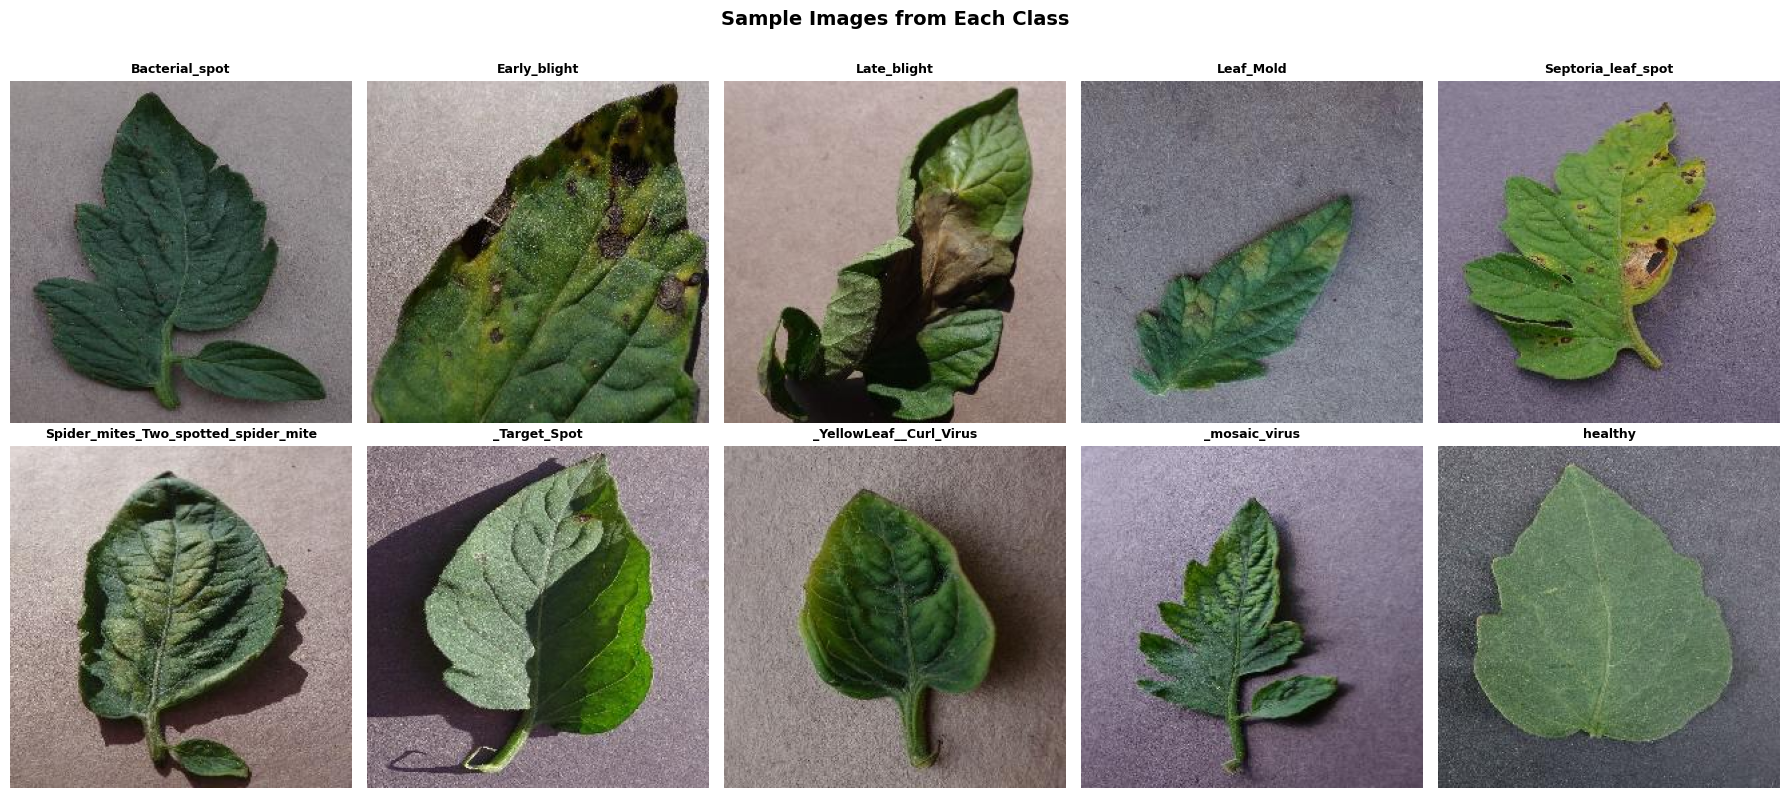

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, cls in enumerate(class_names):
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        img_path = os.path.join(cls_path, imgs[0])
        img = mpimg.imread(img_path)
        axes[idx].imshow(img)
        short_name = cls.replace('Tomato_', '').replace('Tomato__', '').replace('-', '')

        axes[idx].set_title(short_name, fontsize=9, fontweight='bold', wrap=True)
        axes[idx].axis('off')


for i in range(len(class_names), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Sample Images from Each Class',
              fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('EDA_logs/eda_03_sample_images.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved: eda_03_sample_images.png")

### Step 4: Spatial Aspect Ratio & Dimension Plots

#### 4.1 Overview of the Optimization Block
This block performs a deep spatial audit of our image dataset dimensions. Deep learning architectures (like CNNs) operate on fixed-size multi-dimensional pixel arrays and require uniform image dimensions (e.g., $224 \times 224$ or $256 \times 256$) during training. By programmatically sampling the metadata headers of up to 50 images per class, this script generates two histograms and a scatter plot to analyze variations in width, height, and aspect ratios. This visual data confirms whether our raw images are already uniform or if a resizing preprocessing step is mandatory.


#### 4.2 Variable Breakdown Table

| Variable Name | Data Type | Structural Function in Code |
| :--- | :---: | :--- |
| **`widths`** | `list` (Integers) | An accumulation array tracking the horizontal pixel widths of all successfully parsed image assets. |
| **`heights`** | `list` (Integers) | An accumulation array tracking the vertical pixel heights of all successfully parsed image assets. |
| **`sizes_data`** | `list` (Dictionaries) | A storage collection containing structured metadata records for each image to easily build a DataFrame. |
| **`sample`** | `list` (Strings) | A sliced subset array holding up to the first 50 image filenames from the active class folder loop. |
| **`img_file`** | `string` | The active loop iterator variable representing a single specific image filename under inspection. |
| **`img`** | `PIL.PngImagePlugin.PngImageFile` / `JpegImageFile` | The low-level Pillow file handle stream opened to parse metadata attributes. |
| **`w`**, **`h`** | `int`, `int` | Extracted structural parameters representing the explicit width and height pixel boundaries of an image. |
| **`df_sizes`** | `pandas.core.frame.DataFrame` | The finalized master tabular data frame compiled from `sizes_data` for downstream statistical analysis. |
| **`fig`** | `matplotlib.figure.Figure` | The overarching background canvas instance managing the physical 16x5 inch plotting windows. |
| **`axes`** | `numpy.ndarray` (Subplots) | A continuous coordinate grid array managing the execution properties of our 3 horizontal plot panels. |


#### 4.3 Line-by-Line Code Explanation

* `widths, heights, sizes_data = [], [], []`
  * Allocates three empty placeholder data structures to track independent widths, heights, and unified metadata dictionaries.
* `sample = imgs[:50]`
  * Implements an optimized data-sampling slice. Instead of scanning all thousands of images (which slows down execution), it grabs up to the first 50 files from each class folder as a statistical sample.
* `try: ... except Exception as e: pass`
  * Deploys an error-handling wrapper block. If a file is partially corrupted or unreadable, the script bypasses it safely (`pass`) instead of breaking the entire script mid-execution.
* `img = Image.open(os.path.join(cls_path, img_file))`
  * Utilizes Pillow’s lazy-loading engine to read the file header stream, extracting layout specifications without loading the heavy raw pixel data matrix into your computer's RAM.
* `w, h = img.size`
  * Unpacks the image bounding box tuple property into distinct width (`w`) and height (`h`) integer pixel values.
* `sizes_data.append({'class': cls, 'width': w, 'height': h, 'aspect_ratio': round(w/h, 2)})`
  * Appends a clean, structured log dictionary tracking class ownership, spatial dimensions, and the calculated aspect ratio rounded down to two decimal places.
* `df_sizes = pd.DataFrame(sizes_data)`
  * Converts the processed dictionary logs into an organized Pandas DataFrame spreadsheet format, making the raw metrics query-ready.
* `fig, axes = plt.subplots(1, 3, figsize=(16, 5))`
  * Instantiates a single horizontal plot row containing 3 unique multi-panel subplots side-by-side (`1, 3`) wrapped within a 16 by 5 inch canvas layout.
* `axes[0].hist(widths, bins=20, color='steelblue', edgecolor='white')`
  * Constructs a 20-bin histogram on the first plot frame to chart the distribution of width frequencies using a clean steel-blue theme with clear white boundaries.
* `axes[0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {int(np.mean(widths))}px')`
  * Computes the mathematical mean of all widths and strikes a prominent vertical reference axis line (`axvline`) across the chart layout as a red dashed indicator vector.
* `axes[1].hist(heights, bins=20, color='coral', edgecolor='white')`
  * Generates a corresponding 20-bin distribution histogram on the second panel tracking vertical pixel height frequencies using a coral palette theme.
* `axes[2].scatter(widths, heights, alpha=0.3, color='green', s=15)`
  * Maps an analytical scatter correlation plot onto the final panel row, utilizing an overlapping transparency multiplier (`alpha=0.3`) and downscaled dot markers (`s=15`) to visually cluster coordinate groupings.
* `sns.despine()`
  * Trims away the non-essential outer top and right layout frame boundaries, maintaining a sleek, modern graphical presentation footprint.
* `plt.suptitle('Image Size Analysis', fontsize=13, fontweight='bold')`
  * Stamps a centralized bold master header directly over all three multi-panel plots.
* `plt.savefig('EDA_logs/eda_04_image_sizes.png', dpi=150, bbox_inches='tight')`
  * Serializes and stores the complete analytical visualization as a crisp 150 DPI digital asset inside the `EDA_logs` project folder.



🔍 Analyzing image sizes (sampling 50 per class)...


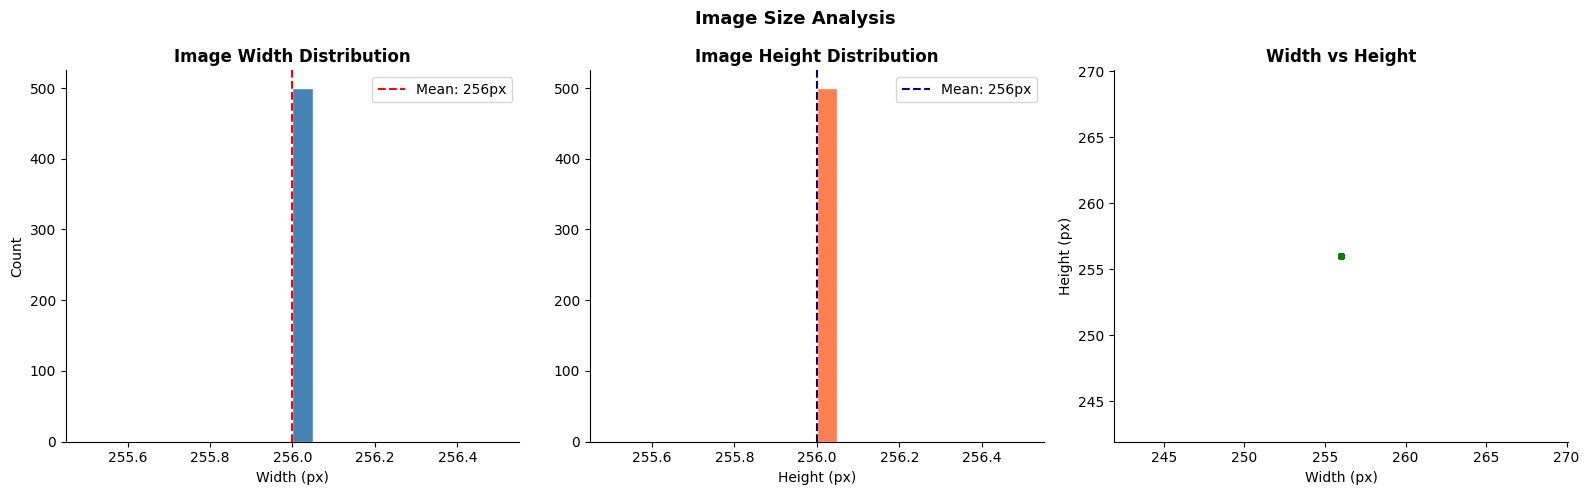

✅ Saved: eda_04_image_sizes.png


In [ ]:
print("\n🔍 Analyzing image sizes (sampling 50 per class)...")

widths, heights, sizes_data = [], [], []

for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample = imgs[:50] 
    for img_file in sample:
        try:
            img = Image.open(os.path.join(cls_path, img_file))
            w, h = img.size
            widths.append(w)
            heights.append(h)
            sizes_data.append({'class': cls, 'width': w, 'height': h,
                               'aspect_ratio': round(w/h, 2)})
        except Exception as e:
            pass

df_sizes = pd.DataFrame(sizes_data)

fig, axes = plt.subplots(1, 3,figsize=(16, 5))

# Image Width Distribution

axes[0].hist(widths, bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Image Width Distribution', fontweight='bold')
axes[0].set_xlabel('Width (px)')
axes[0].set_ylabel('Count')
axes[0].axvline(np.mean(widths), color='red', linestyle='--',
                label=f'Mean: {int(np.mean(widths))}px')
axes[0].legend()

# Height distribution
axes[1].hist(heights, bins=20, color='coral', edgecolor='white')
axes[1].set_title('Image Height Distribution', fontweight='bold')
axes[1].set_xlabel('Height (px)')
axes[1].axvline(np.mean(heights), color='navy', linestyle='--',
                label=f'Mean: {int(np.mean(heights))}px')
axes[1].legend()

# Scatter width vs height
axes[2].scatter(widths, heights, alpha=0.3, color='green', s=15)
axes[2].set_title('Width vs Height', fontweight='bold')
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')

sns.despine()
plt.suptitle('Image Size Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('EDA_logs/eda_04_image_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_04_image_sizes.png")

### Step 5: Color Space Profiling & Channel Analytics

#### 5.1 Overview of the Color Profiling Block
This block handles the color space profiling of our tomato leaf images. Digital images are multi-dimensional matrices constructed from three primary color layers: Red, Green, and Blue (RGB). For botanical computer vision tasks, tracking color profiles is highly important because distinct plant diseases cause unique visual discolorations (e.g., yellow chlorosis spots, brown necrotic spots, or deep dark mold). By processing up to 30 sample images per class, this script flattens the multi-dimensional arrays, isolates each layer channel, and computes their global pixel means to display a distribution histogram. This data provides the exact calibration constants required to handle input normalization when training our deep learning models.


#### 5.2 Variable Breakdown Table

| Variable Name | Data Type | Structural Function in Code |
| :--- | :---: | :--- |
| **`r_means`** | `list` (Floats) | An accumulation array tracking the average pixel intensity of the Red channel across all sampled images. |
| **`g_means`** | `list` (Floats) | An accumulation array tracking the average pixel intensity of the Green channel across all sampled images. |
| **`b_means`** | `list` (Floats) | An accumulation array tracking the average pixel intensity of the Blue channel across all sampled images. |
| **`img_file`** | `string` | The active loop iterator variable representing a single specific image filename under inspection. |
| **`img`** | `numpy.ndarray` (3D RGB Tensor) | The converted raw numerical pixel matrix representing the active leaf photo in a standard 3-layer channel format. |
| **`fig`** | `matplotlib.figure.Figure` | The top-level window layout container controlling our 10x5 inch drawing canvas dimensions. |
| **`ax`** | `matplotlib.axes._subplots.AxesSubplot` | The specific chart coordinate panel where the overlapping color histograms are rendered. |


#### 5.3 Line-by-Line Code Explanation

* `r_means, g_means, b_means = [], [], []`
  * Initializes three empty sequence lists dedicated to independently collecting color intensity averages across our image subsets.
* `img = np.array(Image.open(...).convert('RGB'))`
  * Opens the image file via Pillow, enforces a strict 3-channel standard configuration (`.convert('RGB')`) to strip away any unexpected grayscale or transparency data, and instantly flattens it into a manageable NumPy array matrix.
* `img[:, :, 0].mean()`
  * Uses matrix slicing to isolate the first dimension index (`0`), which represents the complete **Red** channel array, and computes its global arithmetic mean value.
* `img[:, :, 1].mean()`
  * Isolates the second matrix dimension index (`1`), which represents the complete **Green** channel array, to extract its global mean value.
* `img[:, :, 2].mean()`
  * Isolates the final matrix dimension index (`2`), which represents the complete **Blue** channel array, to extract its global mean value.
* `fig, ax = plt.subplots(figsize=(10, 5))`
  * Sets up an explicit, dedicated plotting frame canvas window measuring 10 inches wide by 5 inches high.
* `ax.hist(r_means, bins=30, alpha=0.6, color='red', label='Red channel')`
  * Generates a 30-bin histogram tracking Red channel values. It applies a transparency setting (`alpha=0.6`) so that intersecting distributions beneath it remain fully visible.
* `ax.hist(g_means, bins=30, alpha=0.6, color='green', label='Green channel')`
  * Superimposes a corresponding 30-bin green histogram onto the exact same grid space to directly contrast leaf color profiles.
* `ax.hist(b_means, bins=30, alpha=0.6, color='blue', label='Blue channel')`
  * Overlays the final 30-bin blue histogram on the chart canvas to complete the global RGB profile inspection view.
* `ax.set_xlabel('Mean Pixel Value (0–255)')` & `ax.set_ylabel('Frequency')`
  * Defines labels for the independent variable axis (mapping standard 8-bit color space values from 0 to 255) and the dependent variable axis (tracking the frequency count of matching images).
* `sns.despine()`
  * Drops the top and right boundary coordinate borders from the plot frame window to ensure a clean visual report design.
* `plt.savefig('EDA_logs/eda_05_rgb_channels.png', dpi=150, bbox_inches='tight')`
  * Compiles the finished color-space graphic and saves it out to your storage folder as a crisp 150 DPI digital asset.



🎨 Analyzing RGB channel distributions...


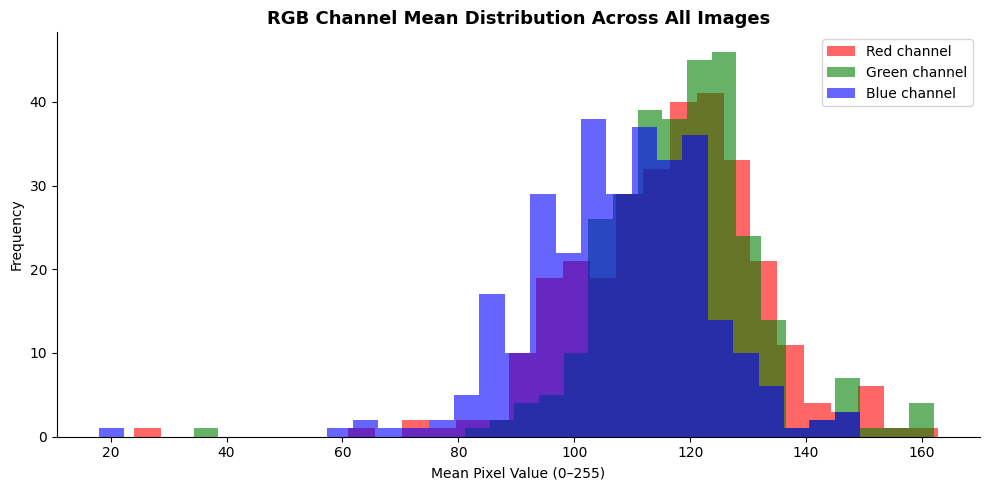

✅ Saved: eda_05_rgb_channels.png


In [41]:
print("\n🎨 Analyzing RGB channel distributions...")
 
r_means, g_means, b_means = [], [], []
 
for cls in class_names:
    cls_path = os.path.join(DATASET_PATH, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for img_file in imgs[:30]:   # 30 samples per class
        try:
            img = np.array(Image.open(
                os.path.join(cls_path, img_file)).convert('RGB'))
            r_means.append(img[:, :, 0].mean())
            g_means.append(img[:, :, 1].mean())
            b_means.append(img[:, :, 2].mean())
        except Exception:
            pass
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(r_means, bins=30, alpha=0.6, color='red',   label='Red channel')
ax.hist(g_means, bins=30, alpha=0.6, color='green', label='Green channel')
ax.hist(b_means, bins=30, alpha=0.6, color='blue',  label='Blue channel')
ax.set_title('RGB Channel Mean Distribution Across All Images',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Pixel Value (0–255)')
ax.set_ylabel('Frequency')
ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('EDA_logs/eda_05_rgb_channels.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: eda_05_rgb_channels.png")

### Step 6: Summary of EDA

#### 6.1 Overview of the Summary Block
This final block serves as the centralized evaluation report for our entire Exploratory Data Analysis (EDA) pipeline. Instead of looking at individual charts, it programmatically collects the statistical summaries computed from Steps 1 through 5—such as global sample volumes, mathematical dimension means, data balance ratios, and core color space weights. Most importantly, it executes an automated threshold evaluation to diagnose whether the dataset suffers from severe class imbalance, providing explicit, data-driven preprocessing recommendations to protect our subsequent Convolutional Neural Network (CNN) training phase from class bias.


#### 6.2 Variable Breakdown Table

| Variable Name | Data Type | Structural Function in Code |
| :--- | :---: | :--- |
| **`max_count`** | `int` | Holds the maximum number of image samples found belonging to the single largest category folder. |
| **`min_count`** | `int` | Holds the minimum number of image samples found belonging to the single smallest category folder. |
| **`imbalance_ratio`** | `float` | The computed statistical factor indicating the scale of variance between your largest and smallest data groups. |

#### 6.3 Line-by-Line Code Explanation

* `max_count = max(class_counts.values())` & `min_count = min(class_counts.values())`
  * Extracts the extreme high and low boundary integers straight from our collected class frequency ledger map values.
* `imbalance_ratio = max_count / min_count`
  * Divides the largest class sample volume by the smallest class sample volume to calculate a normalized imbalance ratio indicator.
* `print("=" * 60)` & `print("  📊 EDA SUMMARY STATISTICS")`
  * Prints a structured ASCII horizontal frame header in the console logs to clearly separate the final data report from the rest of the script outputs.
* `print(f"Max class count : {max_count} ({max(class_counts, key=class_counts.get)})")`
  * Displays the highest class volume alongside the specific directory string name (Key) that holds it, using the `.get` mapping pointer argument.
* `print(f"Mean image width : {int(np.mean(widths))} px")` & `print(f"Mean R channel : {np.mean(r_means):.1f}")`
  * Summarizes and outputs the structural layout dimensions and individual RGB color channels compiled during our spatial and color profiling passes.
* `if imbalance_ratio > 2:`
  * An automated decision-making boundary gate. If the largest data class population outweighs the smallest class population by a scale factor greater than 2x, it triggers the true conditional logical block.
* `print("\n  ⚠️  IMBALANCED dataset detected!")` & `print("     → Guna class_weight atau augmentation...")`
  * Fires a descriptive terminal alert message warning you about structural model bias risks, and suggests explicit, actionable downstream architectural counter-measures (like using focal `class_weight` multipliers or targeted data augmentation loops) to stabilize neural net learning.
* `else: print("\n  ✅ Dataset agak balanced — bagus untuk training!")`
  * If the structural ratio sits safely below or equal to the 2x threshold margin, it outputs a clean validation clearance signal confirming the raw data distribution is uniform enough for training.
* `print("\n  📁 Output files saved: ...")`
  * Displays a physical checklist of all 5 visual asset plots successfully rendered and stored inside the workspace logging cache directory.
* `print("\n✅ EDA COMPLETE! Masukkan findings ni dalam Chapter iv report kau.")`
  * A final confirmation statement reminding the development team to directly transpose these computed key statistics and graphs into **Chapter IV (Results and Discussion)** of the project report or thesis document.


In [1]:
max_count  = max(class_counts.values())
min_count  = min(class_counts.values())
imbalance_ratio = max_count / min_count
 
print("\n" + "=" * 60)
print("  📊 EDA SUMMARY STATISTICS")
print("=" * 60)
print(f"  Total images          : {total_images}")
print(f"  Number of classes     : {len(class_names)}")
print(f"  Mean images per class : {total_images // len(class_names)}")
print(f"  Max class count       : {max_count}  ({max(class_counts, key=class_counts.get)})")
print(f"  Min class count       : {min_count}  ({min(class_counts, key=class_counts.get)})")
print(f"  Imbalance ratio       : {imbalance_ratio:.2f}x")
print(f"  Mean image width      : {int(np.mean(widths))} px")
print(f"  Mean image height     : {int(np.mean(heights))} px")
print(f"  Mean R channel        : {np.mean(r_means):.1f}")
print(f"  Mean G channel        : {np.mean(g_means):.1f}")
print(f"  Mean B channel        : {np.mean(b_means):.1f}")
 
if imbalance_ratio > 2:
    print("\n  ⚠️  IMBALANCED dataset detected!")
    print("     → We will used augmentation for less classes to balance the dataset.")
else:
    print("\n  ✅ Dataset balanced")
 
print("\n  📁 Output files saved:")
print("     eda_01_class_distribution.png")
print("     eda_02_class_proportion.png")
print("     eda_03_sample_images.png")
print("     eda_04_image_sizes.png")
print("     eda_05_rgb_channels.png")
print("\n✅ EDA COMPLETE!")

NameError: name 'class_counts' is not defined